In [1]:
!pip install gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.9 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [4]:
observation, info = env.reset()

print("Observation:")
print(observation)

Observation:
[ 0.04177053 -0.0084265  -0.01325966  0.02676578]


In [5]:
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)


In [6]:
observation, info = env.reset()

total_reward = 0

for step in range(200):
    action = env.action_space.sample()   # Random action

    observation, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    if terminated or truncated:
        break

print("Episode Reward:", total_reward)

Episode Reward: 11.0


In [7]:
import numpy as np

num_bins = 10

bins = [
    np.linspace(-4.8, 4.8, num_bins),
    np.linspace(-4, 4, num_bins),
    np.linspace(-0.418, 0.418, num_bins),
    np.linspace(-4, 4, num_bins)
]

In [8]:
def discretize_state(state):
    state_index = []

    for i in range(len(state)):
        state_index.append(np.digitize(state[i], bins[i]))

    return tuple(state_index)

In [9]:
q_table = np.zeros((11, 11, 11, 11, env.action_space.n))

print(q_table.shape)

(11, 11, 11, 11, 2)


In [10]:
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 500

In [11]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()
    state = discretize_state(state)

    total_reward = 0
    done = False

    while not done:

        # Epsilon-Greedy Action Selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        next_state = discretize_state(next_state)

        # Q-Learning Update
        best_next_action = np.max(q_table[next_state])

        q_table[state][action] = q_table[state][action] + learning_rate * (
            reward + discount_factor * best_next_action - q_table[state][action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode 50, Reward: 15.0, Epsilon: 0.778
Episode 100, Reward: 41.0, Epsilon: 0.606
Episode 150, Reward: 24.0, Epsilon: 0.471
Episode 200, Reward: 12.0, Epsilon: 0.367
Episode 250, Reward: 28.0, Epsilon: 0.286
Episode 300, Reward: 19.0, Epsilon: 0.222
Episode 350, Reward: 26.0, Epsilon: 0.173
Episode 400, Reward: 25.0, Epsilon: 0.135
Episode 450, Reward: 18.0, Epsilon: 0.105
Episode 500, Reward: 25.0, Epsilon: 0.082


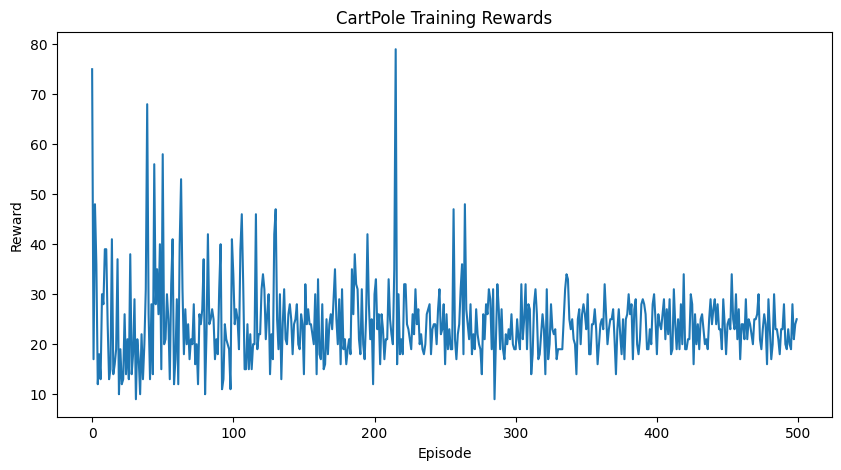

In [12]:
plt.figure(figsize=(10,5))
plt.plot(episode_rewards)

plt.title("CartPole Training Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.show()

In [13]:
state, info = env.reset()
state = discretize_state(state)

total_reward = 0
done = False

while not done:

    action = np.argmax(q_table[state])

    next_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    state = discretize_state(next_state)

    total_reward += reward

print("Test Reward:", total_reward)

Test Reward: 20.0


In [14]:
import numpy as np

np.save("q_table.npy", q_table)

print("Q-table saved successfully!")

Q-table saved successfully!
